In [1]:
print('Welcome To 🏦 Lending Club Loan Data Project!')
# dataset link -> https://www.kaggle.com/datasets/wordsforthewise/lending-club?resource=download

Welcome To 🏦 Lending Club Loan Data Project!


In [2]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#load the dataset
df = pd.read_csv('accepted_lending_club_loan.csv',low_memory=False)
print('Dataset Preview')
df.head()

Dataset Preview


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


###                                            EDA

In [4]:
#dataset shape
print('Dataset shape:',df.shape)

Dataset shape: (2260701, 151)


In [6]:
#dataset dtypes
print('Dataset Datatypes:')
df.dtypes

Dataset Datatypes:


id                        object
member_id                float64
loan_amnt                float64
funded_amnt              float64
funded_amnt_inv          float64
                          ...   
settlement_status         object
settlement_date           object
settlement_amount        float64
settlement_percentage    float64
settlement_term          float64
Length: 151, dtype: object

In [7]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [8]:
df_dtypes_summary = df.dtypes.value_counts().reset_index()
df_dtypes_summary.columns = ['DataType','Count']
print('Total Data Types Count:\n',df_dtypes_summary)

Total Data Types Count:
   DataType  Count
0  float64    113
1   object     38


In [9]:
#dataset statistics
print('Statistics:')
df.describe()

Statistics:


,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,...,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,...,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,...,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,...,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,...,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,...,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


In [10]:
#dulicates check
duplicates = df.duplicated().sum()

if duplicates == 0:
    print('No duplcates found!')
else:
    print(f'{duplicates} Duplicates found!')
    #drop duplicates
    df.drop_duplicates(keep='first',inplace=True)

No duplcates found!


In [12]:
#check missing % 
def check_missing_percent(df):
    null_check = df.isnull().sum()

    missing_df = pd.DataFrame(
      {
        'Feature' : df.columns,
        'Missing_col' : null_check.values,
        'Missing_%' : ((null_check.values) / len(df) * 100)
      }
      )

    missing_df_summary = missing_df[missing_df['Missing_col']>0]

    missing_df_summary = missing_df_summary.sort_values(by='Missing_%',ascending=False)

    if len(missing_df_summary) > 0:
        display(missing_df_summary.style.background_gradient(cmap='Reds',subset='Missing_%'))
    else:
        print('No missing values found!')

    return missing_df_summary    

check_missing_percent(df)
    

,Feature,Missing_col,Missing_%
1,member_id,2260701,100.000000
140,orig_projected_additional_accrued_interest,2252050,99.617331
141,hardship_payoff_balance_amount,2249784,99.517097
142,hardship_last_payment_amount,2249784,99.517097
136,payment_plan_start_date,2249784,99.517097
129,hardship_type,2249784,99.517097
131,hardship_status,2249784,99.517097
134,hardship_start_date,2249784,99.517097
132,deferral_term,2249784,99.517097
133,hardship_amount,2249784,99.517097


,Feature,Missing_col,Missing_%
1,member_id,2260701,100.000000
140,orig_projected_additional_accrued_interest,2252050,99.617331
141,hardship_payoff_balance_amount,2249784,99.517097
142,hardship_last_payment_amount,2249784,99.517097
136,payment_plan_start_date,2249784,99.517097
...,...,...,...
43,total_rec_int,33,0.001460
42,total_rec_prncp,33,0.001460
128,hardship_flag,33,0.001460
143,disbursement_method,33,0.001460


In [12]:
#detecting outliers
numerical_cols = df.select_dtypes(include='float64').columns

outliers_summary = {}

for col in numerical_cols:
    Q3 = df[col].quantile(0.75)
    Q1 = df[col].quantile(0.25)
    IQR = Q3 - Q1

    outliers = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)

    outliers_summary[col] = outliers.sum()    

#converting to dataframe
outliers_df = (pd.DataFrame.from_dict(outliers_summary,orient='index').reset_index())
outliers_df.columns = ['Feature','Outliers_Count'] 
outliers_df= outliers_df.sort_values(by='Outliers_Count',ascending=False)   
#preview the outliers_Df
outliers_df.head(10)

,Feature,Outliers_Count
69,num_accts_ever_120_pd,502976
8,delinq_2yrs,421531
15,pub_rec,357881
37,tot_coll_amt,334263
28,last_pymnt_amnt,313415
85,pub_rec_bankruptcies,271920
20,out_prncp_inv,212305
19,out_prncp,212242
65,mths_since_recent_bc,186169
26,recoveries,185432


In [13]:
#check incosistent data

obj_col = df.select_dtypes(include='object').columns

suspious = []

for col in obj_col:
    try:
       pd.to_numeric(df[col])
       suspious.append(col)
    except:
        pass

suspious    

[]

In [14]:
#check the loan_status counts
loan_status_col = df['loan_status'].value_counts()
#now converting it back to dataframe
loan_status_df = loan_status_col.reset_index()
loan_status_df.columns=['Loan_status','Count'] #renaming the columns
print(loan_status_df)

                                         Loan_status    Count
0                                         Fully Paid  1076751
1                                            Current   878317
2                                        Charged Off   268559
3                                 Late (31-120 days)    21467
4                                    In Grace Period     8436
5                                  Late (16-30 days)     4349
6  Does not meet the credit policy. Status:Fully ...     1988
7  Does not meet the credit policy. Status:Charge...      761
8                                            Default       40


In [15]:
#checking the values in loan status
df['loan_status'].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan,
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [16]:
#taking out only loan related cols
final_loan_status = df[df['loan_status'].isin(['Fully Paid','Charged Off','Default'])]
#print(final_loan_status)

In [17]:
#converting the counts to % 
status_pct = (final_loan_status['loan_status'].value_counts(normalize=True).reset_index())

status_pct.columns = ['Loan Status','Percentage']

status_pct['Percentage'] *= 100

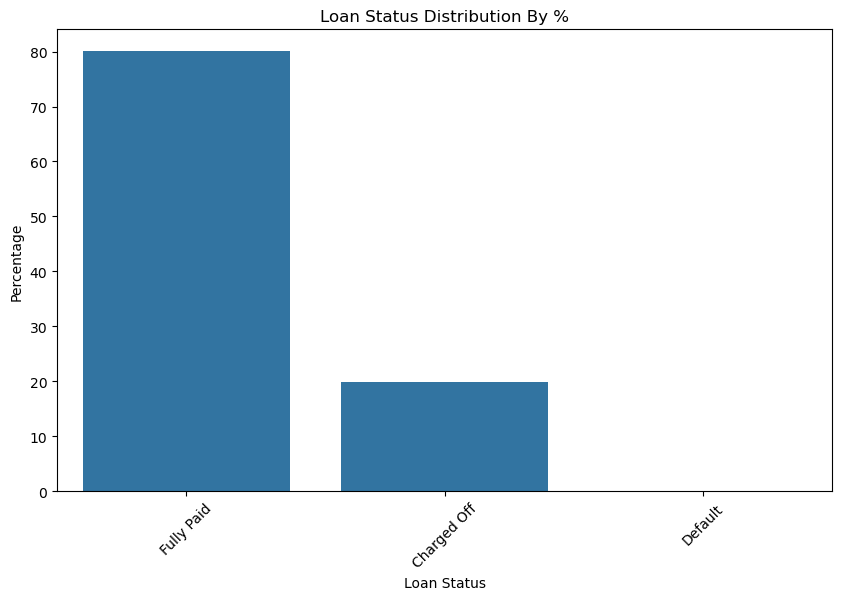

In [18]:
#visualizing the final loan status
plt.figure(figsize=(10,6))
sns.barplot(data=status_pct,x='Loan Status',y='Percentage')
plt.title('Loan Status Distribution By %')
plt.xlabel('Loan Status')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
#plt.tight_layout()
plt.show()

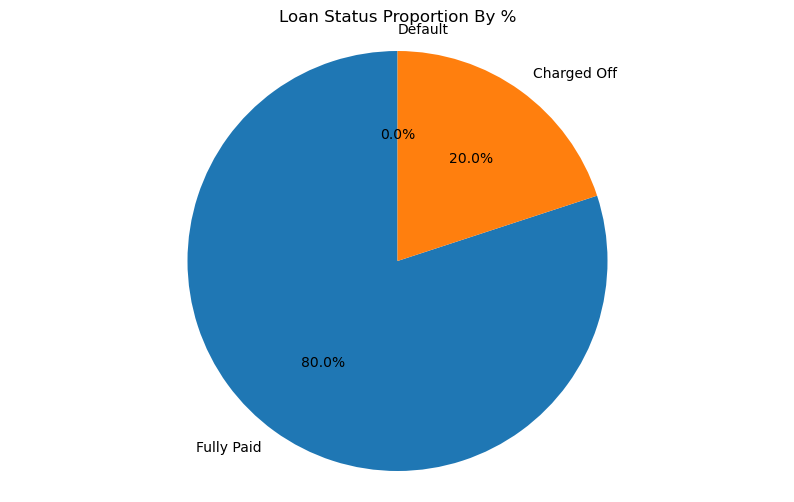

In [19]:
plt.figure(figsize=(10,6))
plt.pie(status_pct['Percentage'],labels=status_pct['Loan Status'],
        startangle=90,autopct='%1.1f%%')
plt.title('Loan Status Proportion By %')
plt.axis('equal')
plt.show()

### EDA Conclusion :
#### 1.For lending club loan dataset the shape is: (2260701, 151) making it large scale dataset.
#### 2.The dataset contains 113 float64 features & 38 object features,No int64 feature present.     
#### 3.No duplicate values were found in the dataset.
#### 4.The dataset contains several features with significant outliers.The column num_accts_ever_120_pd has the highest number of outliers (502,976), followed by delinq_2yrs and pub_rec.
#### 5.There are lot of missing values in the dataset. In particular, member_id is nearly 100% missing, and multiple hardship-related features contain significant missingness.
#### 6.From visualization we can conclude that loan_status has maximum 80.0 % of fully paid & charged_off as 20.0% 
#### 7. No inconsistent data/fetaures were found in the dataset.

### Data Cleaning

In [20]:
#check columns
#list(df.columns)
for col in df.columns:
    print(col)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [21]:

#drop unnecessary columns to prevent data leakage
drop_cols = [
    #Identifiers / Non-predictive 
    'id',
    'member_id',
    'url',
    'desc',
    'title',
    'zip_code',

    #Post-loan / Payment & Recovery
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',

    #Last credit info (future leakage)
    'last_credit_pull_d',
    'last_fico_range_high',
    'last_fico_range_low',

    #Hardship related (post-default)
    'hardship_flag',
    'hardship_type',
    'hardship_reason',
    'hardship_status',
    'deferral_term',
    'hardship_amount',
    'hardship_start_date',
    'hardship_end_date',
    'payment_plan_start_date',
    'hardship_length',
    'hardship_dpd',
    'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',

    #Debt settlement (post-loan) 
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term',

    #Joint applicant (drop for baseline model) 
    'application_type',
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'revol_bal_joint',

    #Secondary applicant columns
    'sec_app_fico_range_low',
    'sec_app_fico_range_high',
    'sec_app_earliest_cr_line',
    'sec_app_inq_last_6mths',
    'sec_app_mort_acc',
    'sec_app_open_acc',
    'sec_app_revol_util',
    'sec_app_open_act_il',
    'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog'
]

df = df.drop(columns=drop_cols,errors='ignore')

In [22]:
#check shape after dropping unnecessary cols
print('Data Shape after dropping the unnecessary columns:',df.shape)

Data Shape after dropping the unnecessary columns: (2260701, 91)


In [23]:
#check null % after removing unnecessary columns
def check_missing_percent(df):
    null_check = df.isnull().sum()

    missing_df = pd.DataFrame(
      {
        'Feature' : df.columns,
        'Missing_col' : null_check.values,
        'Missing_%' : ((null_check.values) / len(df) * 100)
      }
      )

    missing_df_summary = missing_df[missing_df['Missing_col']>0]

    missing_df_summary = missing_df_summary.sort_values(by='Missing_%',ascending=False)

    if len(missing_df_summary) > 0:
        display(missing_df_summary.style.background_gradient(cmap='Reds',subset='Missing_%'))
    else:
        print('No missing values found!')

    return missing_df_summary    

In [24]:
missing_df_summary = check_missing_percent(df)

,Feature,Missing_col,Missing_%
25,mths_since_last_record,1901545,84.113069
65,mths_since_recent_bc_dlq,1741000,77.011511
33,mths_since_last_major_derog,1679926,74.309960
67,mths_since_recent_revol_delinq,1520342,67.250910
24,mths_since_last_delinq,1158535,51.246715
44,il_util,1068883,47.281042
42,mths_since_rcnt_il,909957,40.251099
48,all_util,866381,38.323555
51,total_cu_tl,866163,38.313912
52,inq_last_12m,866163,38.313912


In [25]:
#drop the columns whose % is > 70 % 
col_70 = missing_df_summary[missing_df_summary['Missing_%']>70]['Feature'].tolist()
print(col_70)
df = df.drop(columns=col_70,errors='ignore')
df.head()

['mths_since_last_record', 'mths_since_recent_bc_dlq', 'mths_since_last_major_derog']


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,...,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,...,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,...,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash
3,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,...,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,Cash
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,...,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash


In [26]:
#extracting columns whose % is between 40% - 70%
col_40_70 = missing_df_summary[(missing_df_summary['Missing_%']>=40) & (missing_df_summary['Missing_%']<=70)]['Feature'].tolist()
print(col_40_70)

['mths_since_recent_revol_delinq', 'mths_since_last_delinq', 'il_util', 'mths_since_rcnt_il']


In [27]:
#creating missingness flag
df['recent_revol_delinq_missing'] = df['mths_since_recent_revol_delinq'].isna().astype(int)
df['last_delinq_missing'] = df['mths_since_last_delinq'].isna().astype(int)

In [28]:
#impute missing values with large value
df['mths_since_recent_revol_delinq'] = df['mths_since_recent_revol_delinq'].fillna(999)
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)

In [29]:
#dropping 'il_util', 'mths_since_rcnt_il' -> These variables were excluded initially due to limited coverage and marginal interpretability impact.
df.drop(columns=['il_util', 'mths_since_rcnt_il'],inplace=True)

In [30]:
dropped_cols = ['il_util', 'mths_since_rcnt_il']
print("Dropped columns due to high missingness / low coverage:", dropped_cols)

Dropped columns due to high missingness / low coverage: ['il_util', 'mths_since_rcnt_il']


In [31]:
df.head(3)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,recent_revol_delinq_missing,last_delinq_missing
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,1,1


In [32]:
#check missing % 
def check_missing_percent(df):
    null_check = df.isnull().sum()

    missing_df = pd.DataFrame(
      {
        'Feature' : df.columns,
        'Missing_col' : null_check.values,
        'Missing_%' : ((null_check.values) / len(df) * 100)
      }
      )

    missing_df_summary = missing_df[missing_df['Missing_col']>0]

    missing_df_summary = missing_df_summary.sort_values(by='Missing_%',ascending=False)

    if len(missing_df_summary) > 0:
        display(missing_df_summary.style.background_gradient(cmap='Reds',subset='Missing_%'))
    else:
        print('No missing values found!')

    return missing_df_summary    

missing_df_summary = check_missing_percent(df)


,Feature,Missing_col,Missing_%
44,all_util,866381,38.323555
47,total_cu_tl,866163,38.313912
36,open_acc_6m,866163,38.313912
48,inq_last_12m,866163,38.313912
40,total_bal_il,866162,38.313868
41,open_rv_12m,866162,38.313868
39,open_il_24m,866162,38.313868
37,open_act_il,866162,38.313868
43,max_bal_bc,866162,38.313868
42,open_rv_24m,866162,38.313868


In [33]:
missing_flag_cols = [
    'all_util',
    'total_cu_tl',
    'open_acc_6m',
    'inq_last_12m',
    'total_bal_il',
    'open_rv_12m',
    'open_il_24m',
    'open_act_il',
    'max_bal_bc',
    'open_rv_24m',
    'inq_fi',
    'open_il_12m',
    'mths_since_recent_inq',
    'num_tl_120dpd_2m',
    'mo_sin_old_il_acct'
]

for col in missing_flag_cols:
    df[col + '_missing'] = df[col].isna().astype(int)


In [34]:
#filling textual or demographic fields with unknown
df['emp_title'] = df['emp_title'].fillna('Unknown')
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [35]:
credit_cols = [
    'all_util','total_cu_tl','open_acc_6m','inq_last_12m','total_bal_il',
    'open_rv_12m','open_il_24m','open_act_il','max_bal_bc','open_rv_24m',
    'inq_fi','open_il_12m'
]

for col in credit_cols:
    df[col] = df[col].fillna(df[col].median())

In [36]:
# time-since
df['mths_since_recent_inq'] = df['mths_since_recent_inq'].fillna(df['mths_since_recent_inq'].max() + 1)

df['mo_sin_old_il_acct'] = df['mo_sin_old_il_acct'].fillna(df['mo_sin_old_il_acct'].max() + 1)

In [37]:
# delinquency
df['num_tl_120dpd_2m'] = df['num_tl_120dpd_2m'].fillna(0)

In [38]:
categorical_cols = [
    "earliest_cr_line",
    "issue_d",
    "pymnt_plan",
    "loan_status",
    "initial_list_status",
    "disbursement_method"
]

time_cols_low_missing = [
    "earliest_cr_line",
    "issue_d"
]

num_cols_low_missing = [
    "pct_tl_nvr_dlq",
    "total_il_high_credit_limit",
    "tot_hi_cred_lim",
    "total_rev_hi_lim",
    "tot_coll_amt",
    "total_bc_limit",
    "total_bal_ex_mort",
    "delinq_amnt",
    "installment",
    "funded_amnt",
    "loan_amnt",
    "int_rate",
    "funded_amnt_inv",
    "policy_code",
    "fico_range_low",
    "fico_range_high"
]

count_cols_low_missing = [
    "num_rev_accts",
    "num_accts_ever_120_pd",
    "num_actv_bc_tl",
    "num_il_tl",
    "num_actv_rev_tl",
    "num_bc_tl",
    "num_tl_op_past_12m",
    "num_op_rev_tl",
    "num_rev_tl_bal_gt_0",
    "num_bc_sats",
    "num_sats",
    "mort_acc",
    "acc_open_past_24mths",
    "pub_rec_bankruptcies",
    "inq_last_6mths",
    "open_acc"
]

In [39]:
# --- Convert time columns to datetime ---
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

# --- Impute numeric columns (median) ---
for col in num_cols_low_missing:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# --- Impute count columns (fill with 0) ---
for col in count_cols_low_missing:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# --- Impute categorical columns (mode) ---
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# --- Impute time columns (mode instead of median) ---
for col in time_cols_low_missing:
    if col in df.columns:
        # mode()[0] gives the most frequent date
        df[col] = df[col].fillna(df[col].mode()[0])

In [40]:
#check missing % 
def check_missing_percent(df):
    null_check = df.isnull().sum()

    missing_df = pd.DataFrame(
      {
        'Feature' : df.columns,
        'Data Type' :[df[col].dtype for col in df.columns],
        'Missing_col' : null_check.values,
        'Missing_%' : ((null_check.values) / len(df) * 100)
      }
      )

    missing_df_summary = missing_df[missing_df['Missing_col']>0]

    missing_df_summary = missing_df_summary.sort_values(by='Missing_%',ascending=False)

    if len(missing_df_summary) > 0:
        display(missing_df_summary.style.background_gradient(cmap='Reds',subset='Missing_%'))
    else:
        print('No missing values found!')

    return missing_df_summary    

missing_df_summary = check_missing_percent(df)


,Feature,Data Type,Missing_col,Missing_%
52,bc_util,float64,76104,3.366389
78,percent_bc_gt_75,float64,75412,3.335779
51,bc_open_to_buy,float64,74968,3.316140
60,mths_since_recent_bc,float64,73445,3.248771
50,avg_cur_bal,float64,70379,3.113149
57,mo_sin_rcnt_rev_tl_op,float64,70310,3.110097
56,mo_sin_old_rev_tl_op,float64,70310,3.110097
35,tot_cur_bal,float64,70309,3.110053
58,mo_sin_rcnt_tl,float64,70309,3.110053
74,num_tl_30dpd,float64,70309,3.110053


In [41]:
# Categorical columns
categorical_cols = [
    "verification_status",
    "purpose",
    "addr_state",
    "term",
    "grade",
    "sub_grade",
    "home_ownership"
]

# Time columns with low missingness (none in this batch)
time_cols_low_missing = []

# Numeric columns with low missingness
num_cols_low_missing = [
    "avg_cur_bal",
    "tot_cur_bal",
    "revol_util",
    "dti",
    "annual_inc",
    "revol_bal",
    "bc_util",
    "percent_bc_gt_75",
    "bc_open_to_buy"
]

# Count columns with low missingness
count_cols_low_missing = [
    "mo_sin_rcnt_rev_tl_op",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_tl",
    "num_tl_30dpd",
    "num_tl_90g_dpd_24m",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "tax_liens",
    "delinq_2yrs",
    "total_acc",
    "pub_rec",
    "acc_now_delinq",
    "mths_since_recent_bc"
]

In [42]:
# --- Impute numeric columns (median) ---
for col in num_cols_low_missing:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# --- Impute count columns (fill with 0) ---
for col in count_cols_low_missing:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# --- Impute categorical columns (mode) ---
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# --- Time columns (none in this batch, so skip) ---
for col in time_cols_low_missing:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [43]:
#check missing % 
def check_missing_percent(df):
    null_check = df.isnull().sum()

    missing_df = pd.DataFrame(
      {
        'Feature' : df.columns,
        'Data Type' :[df[col].dtype for col in df.columns],
        'Missing_col' : null_check.values,
        'Missing_%' : ((null_check.values) / len(df) * 100)
      }
      )

    missing_df_summary = missing_df[missing_df['Missing_col']>0]

    missing_df_summary = missing_df_summary.sort_values(by='Missing_%',ascending=False)

    if len(missing_df_summary) > 0:
        display(missing_df_summary.style.background_gradient(cmap='Reds',subset='Missing_%'))
    else:
        print('No missing values found!')

    return missing_df_summary    

missing_df_summary = check_missing_percent(df)


No missing values found!


### Data Cleaning Summary:
#### 1.Dropped unnecessary columns to prevent data leakage.
#### 2.Dropped columns whose % is greater 70%.
#### 3.For 5–40% created  missing flags + did imputation.
#### 4.For <5% did simple imputation.

#### Define binary target & remove leakage

In [44]:
# target distribution
df['loan_status'].value_counts(normalize=True)

loan_status
Fully Paid                                             0.476305
Current                                                0.388515
Charged Off                                            0.118795
Late (31-120 days)                                     0.009496
In Grace Period                                        0.003732
Late (16-30 days)                                      0.001924
Does not meet the credit policy. Status:Fully Paid     0.000879
Does not meet the credit policy. Status:Charged Off    0.000337
Default                                                0.000018
Name: proportion, dtype: float64

In [45]:
#converting loan_status to binary classification
df['target'] = df['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default', 'Late (31-120 days)'] else 0)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_24272\4232404397.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default', 'Late (31-120 days)'] else 0)


In [46]:
#check class imbalance
df['target'].value_counts()
df['target'].value_counts(normalize=True).reset_index().rename(columns={'index':'Target','target':'Proportion'})

,Proportion,proportion
0,0,0.871692
1,1,0.128308


In [47]:
#drop the post-disbursement and repayment-related variables to avoid future leakage 
leakage_cols = [ 'last_pymnt_d','last_pymnt_amnt','next_pymnt_d', 'total_rec_prncp','total_rec_int','total_rec_late_fee',
                 'recoveries','collection_recovery_fee','out_prncp', 'out_prncp_inv' ]

df = df.drop(columns=leakage_cols,errors='ignore')

### Feature Engineering

In [48]:
'emp_length' in df.columns

True

#### Encode categorical features

In [49]:
#extracting date columns
date_cols = df.select_dtypes(include='datetime64').columns.to_list()
date_cols

['issue_d', 'earliest_cr_line']

In [50]:
#drop unnecessary date col
df = df.drop(columns=['issue_d'],errors='ignore')

In [51]:
#Convert dates → numeric “age” features
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

df['credit_history_months'] = (
    (pd.to_datetime('today') - df['earliest_cr_line']).dt.days // 30
)

df = df.drop(columns=['earliest_cr_line'])


C:\Users\NEHA\AppData\Local\Temp\ipykernel_24272\2117759942.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['credit_history_months'] = (


In [52]:
#extracting categorical columns
cat_cols = df.select_dtypes(include='object').columns.to_list()
cat_cols

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'addr_state',
 'initial_list_status',
 'disbursement_method']

In [53]:
#noisy column & weak preddictive
df = df.drop(columns=['emp_title'])

In [54]:
#term check
df['term'].value_counts()

term
36 months    1609787
60 months     650914
Name: count, dtype: int64

In [55]:
#encoding term
df['term'] = df['term'].str.strip().map({'36 months':36,'60 months':60})

In [56]:
#check the map to ensure
df['term'].value_counts()

term
36    1609787
60     650914
Name: count, dtype: int64

In [57]:
#encoding pymnt_plan 'y' = payment plan exists --> 'n' = no payment plan
df['pymnt_plan'] = df['pymnt_plan'].map({'n':0,'y':1})

In [58]:
#grade
grade_map = {
    'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7
    }

df['grade_enc'] = df['grade'].map(grade_map)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_24272\43320486.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['grade_enc'] = df['grade'].map(grade_map)


In [59]:
#sub_grade
df['sub_grade_enc'] = df['sub_grade'].str[0].map(grade_map)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_24272\2673322926.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sub_grade_enc'] = df['sub_grade'].str[0].map(grade_map)


In [60]:
#emp_length
emp_map = {
    '10+ years':10, '9 years':9, '8 years':8, '7 years':7,
    '6 years':6, '5 years':5, '4 years':4, '3 years':3,
    '2 years':2, '1 year':1, '< 1 year':0, 'Unknown':-1
}
df['emp_length_enc'] = df['emp_length'].map(emp_map)


C:\Users\NEHA\AppData\Local\Temp\ipykernel_24272\4030278523.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['emp_length_enc'] = df['emp_length'].map(emp_map)


In [61]:
#drop the original columns
df = df.drop(columns=['grade','sub_grade','emp_length'])

#### Nominal encoding

In [62]:
#ohe for nominal columns
nominal_cols = [
    'purpose','home_ownership','addr_state',
    'verification_status','initial_list_status',
    'disbursement_method'
]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)


In [63]:
#import sklearn libraries
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [64]:
#feature selection
x = df.drop(['target','loan_status'],axis=1)
y = df['target']

In [104]:
feature_cols = x.columns.to_list()
feature_cols

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'annual_inc',
 'pymnt_plan',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'collections_12_mths_ex_med',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'total_bal_il',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_inq',
 'mths_since_recent_revol_delinq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_t

In [65]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.20,stratify=y)

In [66]:
x_train.isnull().sum().sort_values(ascending=False).head(15)

loan_amnt                 0
funded_amnt               0
funded_amnt_inv           0
term                      0
int_rate                  0
installment               0
annual_inc                0
pymnt_plan                0
dti                       0
delinq_2yrs               0
fico_range_low            0
fico_range_high           0
inq_last_6mths            0
mths_since_last_delinq    0
open_acc                  0
dtype: int64

In [67]:
#creating object for standard scaler
scaler = StandardScaler()

In [68]:
#fit & transform the x_train & x_test
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Feature Encoding,Feature Selection & Scaling Summary:
#### 1.Applied ordinal encoding where order matters and one-hot encoding for nominal variables.
#### 2.Encoded categorical columns.Also dropped uncessary columns.
#### 3.Encode date time columns whereas dropped uncessary columns.
#### 2.Selected the appropriate feature for train & test.
#### 3.Performed standardization on train & test features.

### Train The Model

In [69]:
#import the logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)

#fit the train the data
lr.fit(x_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Get Predictions

In [70]:
#check prediction
y_train_pred = lr.predict(x_train_scaled)
y_test_pred = lr.predict(x_test_scaled)

#- extracting the probability of class 1 for each sample.
y_test_proba = lr.predict_proba(x_test_scaled)[:,1]

### Model Evaluation

In [71]:
#roc_auc score 
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(y_train,lr.predict_proba(x_train_scaled)[:,1])
test_auc = roc_auc_score(y_test,y_test_proba)

print(f"Train ROC AUC:{train_auc:.3f}")
print(f"Test ROC AUC: {test_auc:.3f}")

Train ROC AUC:0.728
Test ROC AUC: 0.728


In [72]:
#confusion matrix & classification report
from sklearn.metrics import confusion_matrix,classification_report

print("Confusion Matrix:\n",confusion_matrix(y_test,y_test_pred))
print("Classification Report:\n",classification_report(y_test,y_test_pred))

Confusion Matrix:
 [[260178 133950]
 [ 19280  38733]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77    394128
           1       0.22      0.67      0.34     58013

    accuracy                           0.66    452141
   macro avg       0.58      0.66      0.55    452141
weighted avg       0.84      0.66      0.72    452141



#### The baseline logistic regression achieves a ROC-AUC of ~0.73 with strong recall on defaulters. The confusion matrix reflects a conservative risk posture at a 0.5 threshold, which we later refine using KS and business-driven threshold tuning.

### KS Statistic

KS = max(TPR − FPR) across all thresholds
KS > 0.30 → good

KS > 0.40 → strong

KS < 0.20 → weak

### Stratified Cross-Validation + Hyperparameter Tuning (Logistic)

In [73]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split

#
X_tune, _, y_tune, _ = train_test_split(
    x_train_scaled,
    y_train,
    test_size=0.7,
    stratify=y_train,
    random_state=42
)

lr = LogisticRegression(
    solver='saga',          # fast for large data
    penalty='l2',
    class_weight='balanced',
    max_iter=300,
    n_jobs=1,
    random_state=42
)

param_grid = {
    'C': [0.1, 1, 5]
}

skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    lr,
    param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=1,
    verbose=1
)

grid.fit(X_tune, y_tune)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

# Train final tuned model on FULL training data
best_lr = grid.best_estimator_
best_lr.fit(x_train_scaled, y_train)


Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\NEHA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\NEHA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\NEHA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\NEHA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\NEHA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\NEHA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was re

Best params: {'C': 5}
Best CV AUC: 0.7269923710313321


c:\Users\NEHA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=5, class_weight='balanced', max_iter=300, n_jobs=1,
                   random_state=42, solver='saga')

In [74]:
import numpy as np
from sklearn.metrics import roc_curve

y_test_proba = best_lr.predict_proba(x_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
ks_values = tpr - fpr

ks = ks_values.max()
ks_threshold = thresholds[np.argmax(ks_values)]

print(f"KS Statistic: {ks:.3f}")
print(f"KS Threshold: {ks_threshold:.3f}")


KS Statistic: 0.329
KS Threshold: 0.473


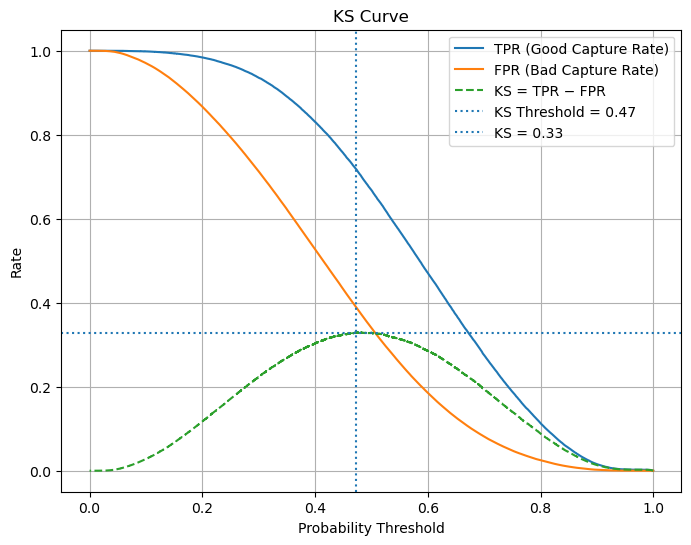

In [76]:
#plot the ks curve
# Probabilities from tuned model
y_test_proba = best_lr.predict_proba(x_test_scaled)[:, 1]

# ROC components
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# KS values
ks_values = tpr - fpr
ks = ks_values.max()
ks_threshold = thresholds[np.argmax(ks_values)]

# Plot KS Curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, tpr, label='TPR (Good Capture Rate)')
plt.plot(thresholds, fpr, label='FPR (Bad Capture Rate)')
plt.plot(thresholds, ks_values, label='KS = TPR − FPR', linestyle='--')

# KS point
plt.axvline(x=ks_threshold, linestyle=':', label=f'KS Threshold = {ks_threshold:.2f}')
plt.axhline(y=ks, linestyle=':', label=f'KS = {ks:.2f}')

plt.xlabel("Probability Threshold")
plt.ylabel("Rate")
plt.title("KS Curve")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
from sklearn.metrics import confusion_matrix, classification_report

y_test_pred_ks = (y_test_proba >= ks_threshold).astype(int)

print("Confusion Matrix (KS Threshold):")
print(confusion_matrix(y_test, y_test_pred_ks))

print("\nClassification Report (KS Threshold):")
print(classification_report(y_test, y_test_pred_ks))

Confusion Matrix (KS Threshold):
[[241148 152980]
 [ 16406  41607]]

Classification Report (KS Threshold):
              precision    recall  f1-score   support

           0       0.94      0.61      0.74    394128
           1       0.21      0.72      0.33     58013

    accuracy                           0.63    452141
   macro avg       0.58      0.66      0.53    452141
weighted avg       0.84      0.63      0.69    452141



### Xgboost

In [79]:
# ! pip install xgboost

In [80]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,          
    max_depth=5,               
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),  
    random_state=42,
    n_jobs=4                   
    )

xgb.fit(x_train_scaled,y_train)

#probabilities
y_train_xgb_proba = xgb.predict_proba(x_train_scaled)[:,1]
y_test_xgb_proba = xgb.predict_proba(x_test_scaled)[:,1]

#roc-auc
print("XGB Train AUC:",roc_auc_score(y_train,y_train_xgb_proba))
print("XGB Test AUC:",roc_auc_score(y_test,y_test_xgb_proba))

XGB Train AUC: 0.745725853530903
XGB Test AUC: 0.7431375446693378


In [81]:
#KS for Xgb
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_test_xgb_proba)
ks_values = tpr - fpr

ks_xgb = ks_values.max()
ks_threshold_xgb = thresholds[np.argmax(ks_values)]

print("XGB KS:", ks_xgb)
print("XGB KS Threshold:", ks_threshold_xgb)

XGB KS: 0.35306719370225803
XGB KS Threshold: 0.49932024


In [ ]:
#evaluation at threshold 
y_test_pred_xgb_ks = (y_test_xgb_proba >= ks_threshold_xgb).astype(int)

print('Confusion Matrix:\n',confusion_matrix(y_test, y_test_pred_xgb_ks))
print('Classification Report:\n',classification_report(y_test, y_test_pred_xgb_ks))


Confusion Matrix:
 [[255803 138325]
 [ 17170  40843]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.65      0.77    394128
           1       0.23      0.70      0.34     58013

    accuracy                           0.66    452141
   macro avg       0.58      0.68      0.56    452141
weighted avg       0.85      0.66      0.71    452141



### Random Forest for comaparision

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,          # not too many
    max_depth=12,              # control overfitting
    min_samples_leaf=50,       # very important for stability
    class_weight='balanced',
    n_jobs=4,
    random_state=42
)

rf.fit(x_train_scaled, y_train)

# Probabilities
y_train_proba_rf = rf.predict_proba(x_train_scaled)[:, 1]
y_test_proba_rf = rf.predict_proba(x_test_scaled)[:, 1]

print("RF Train AUC:", roc_auc_score(y_train, y_train_proba_rf))
print("RF Test AUC:", roc_auc_score(y_test, y_test_proba_rf))


RF Train AUC: 0.7466059645025038
RF Test AUC: 0.7282367358273404


In [86]:
#KS for RF
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_rf)
ks_values = tpr - fpr

ks_rf = ks_values.max()
ks_threshold_rf = thresholds[np.argmax(ks_values)]

print("RF KS:", ks_rf)
print("RF KS Threshold:", ks_threshold_rf)


RF KS: 0.3306169075411979
RF KS Threshold: 0.48928645468003235


In [87]:
#evaluation for rf
y_test_pred_rf_ks = (y_test_proba_rf >= ks_threshold_rf).astype(int)

print(confusion_matrix(y_test, y_test_pred_rf_ks))
print(classification_report(y_test, y_test_pred_rf_ks))


[[250141 143987]
 [ 17639  40374]]
              precision    recall  f1-score   support

           0       0.93      0.63      0.76    394128
           1       0.22      0.70      0.33     58013

    accuracy                           0.64    452141
   macro avg       0.58      0.67      0.54    452141
weighted avg       0.84      0.64      0.70    452141



### SHAP Explainability

In [89]:
#! pip install shap

In [91]:
#create a shap explainer
import shap
#background to save memory
background = x_train_scaled[:1000]

explainer = shap.TreeExplainer(xgb,background)

In [92]:
#compute shap test
x_shap = x_test_scaled[:2000]

shap_values = explainer.shap_values(x_shap)

 95%|=================== | 1907/2000 [00:13<00:00]       

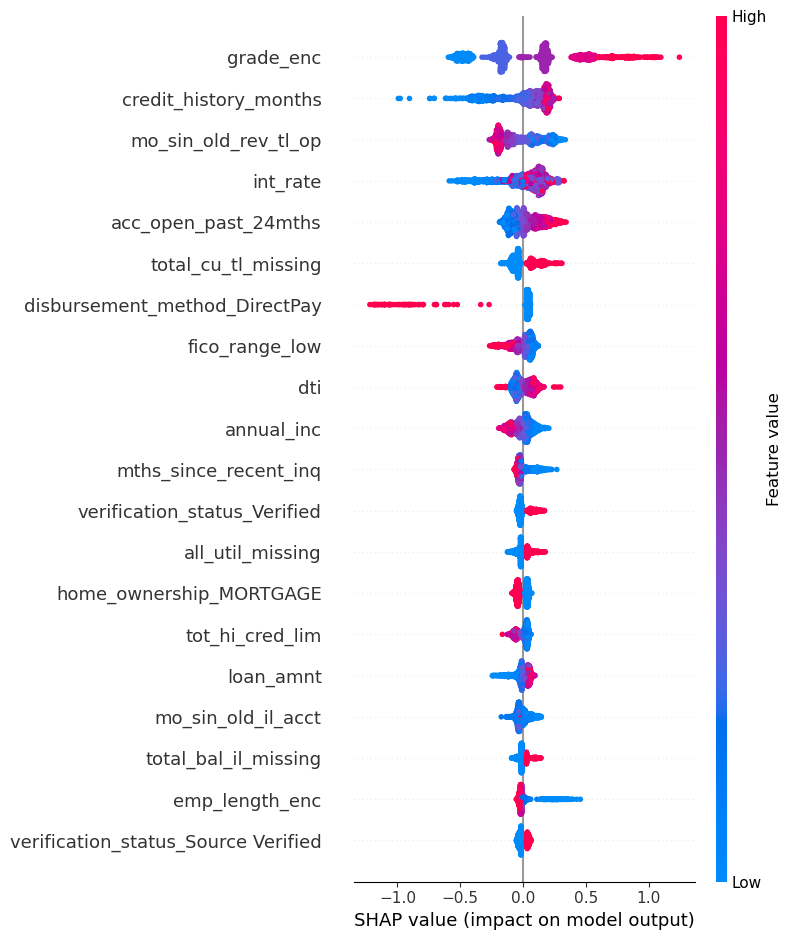

In [93]:
#shap summary plot
shap.summary_plot(
    shap_values,x_shap,feature_names=x.columns,show=True
)

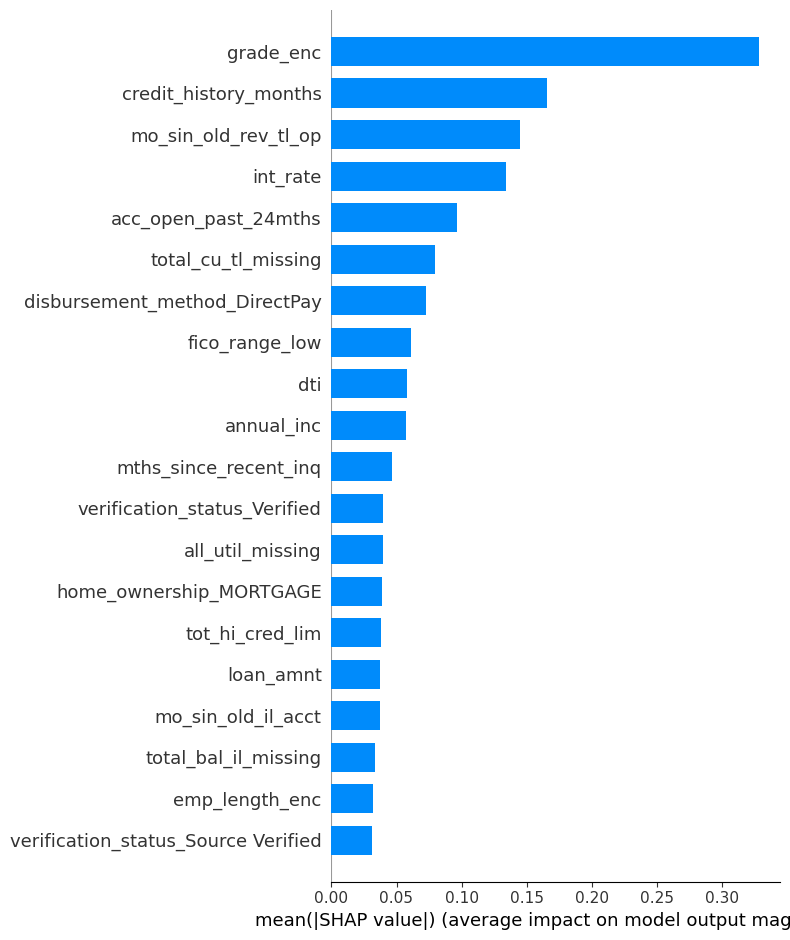

In [94]:
#shap summary barplot
shap.summary_plot(
    shap_values,x_shap,feature_names=x.columns,show=True,plot_type ='bar'
)

### Business Loss Optimization

In [96]:
#define loss function
def business_loss(y_true, y_pred,cost_fn=50000,cost_fp=5000):
    
      tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
      total_loss = (fn * cost_fn) + (fp * cost_fp)
      return total_loss

In [97]:
#try multiple threshold 
thresholds = np.arange(0.1, 0.9, 0.02)
losses = []

for t in thresholds:
    y_pred = (y_test_proba >= t).astype(int)
    loss = business_loss(y_test, y_pred)
    losses.append(loss)

In [98]:
#best business threshold
best_idx = np.argmin(losses)
best_threshold_business = thresholds[best_idx]

print("Best Business Threshold:", best_threshold_business)
print("Minimum Business Loss:", losses[best_idx])


Best Business Threshold: 0.38
Minimum Business Loss: 1530580000


In [99]:
#evaluate model at business threshold
y_test_pred_business = (y_test_proba >= best_threshold_business).astype(int)

from sklearn.metrics import classification_report

print("Confusion Matrix (Business Threshold):")
print(confusion_matrix(y_test, y_test_pred_business))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_business))


Confusion Matrix (Business Threshold):
[[171312 222816]
 [  8330  49683]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.43      0.60    394128
           1       0.18      0.86      0.30     58013

    accuracy                           0.49    452141
   macro avg       0.57      0.65      0.45    452141
weighted avg       0.85      0.49      0.56    452141



#### Instead of using a fixed threshold, I optimized the decision cutoff based on a business loss function. Since missing a defaulter is far more costly than rejecting a good customer, I assigned higher cost to false negatives and selected the threshold that minimized total financial loss.”

### Deployment

In [101]:
import joblib

joblib.dump(best_lr, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_cols, "features.pkl")
joblib.dump(best_threshold_business, "threshold.pkl")


['threshold.pkl']

In [103]:
#! pip install fastapi uvicorn